In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (precision_recall_curve, average_precision_score, roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Optional models
try:
    import xgboost as xgb
except Exception as e:
    xgb = None
    print('XGBoost not available: ', e)
try:
    import lightgbm as lgb
except Exception as e:
    lgb = None
    print('LightGBM not available:', e)

import joblib
print('Setup complete')

Setup complete


In [3]:
# 1. Load data
DATA_PATH = 'creditcard.csv'   # ensure file is in same directory
assert os.path.exists(DATA_PATH), f"Dataset not found at {DATA_PATH}. Please place creditcard.csv next to the notebook."
df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Rows, Columns: (284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values (top 20): 
 Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
V21       0
V20       0
V19       0
V18       0
V17       0
V15       0
V1        0
V14       0
V13       0
V12       0
dtype: int64

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud ratio: 0.001727485630620034


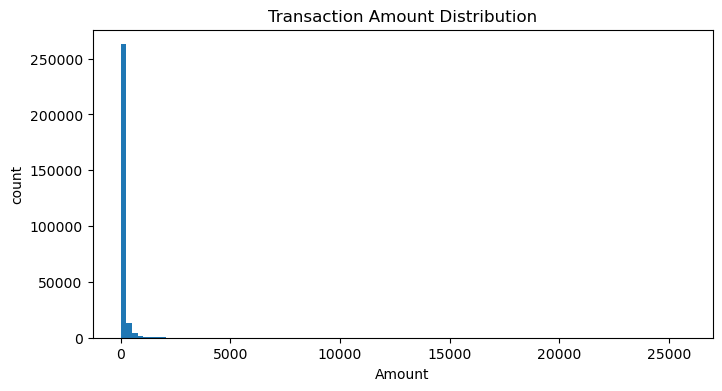

In [4]:
# 2. Quick EDA
print('Rows, Columns:', df.shape)
print(df.dtypes)
print('\nMissing values (top 20): \n', df.isnull().sum().sort_values(ascending=False).head(20))
target_col = 'Class'
print('\nTarget distribution:')
print(df[target_col].value_counts())
print('Fraud ratio:', df[target_col].mean())

# Amount distribution
plt.figure(figsize=(8,4))
plt.hist(df['Amount'], bins=100)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('count')
plt.show()

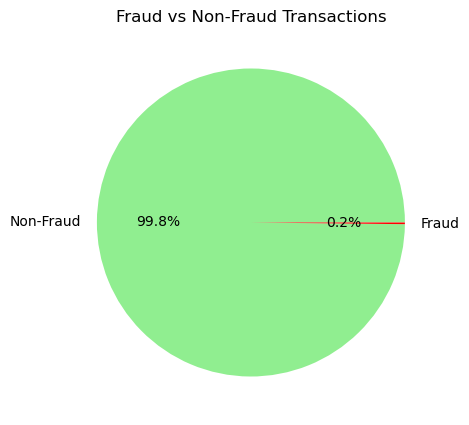

In [5]:
# Pie chart
plt.figure(figsize=(5,5))
plt.pie(df['Class'].value_counts().values, labels=['Non-Fraud', 'Fraud'], autopct='%1.1f%%', colors=['lightgreen', 'red'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

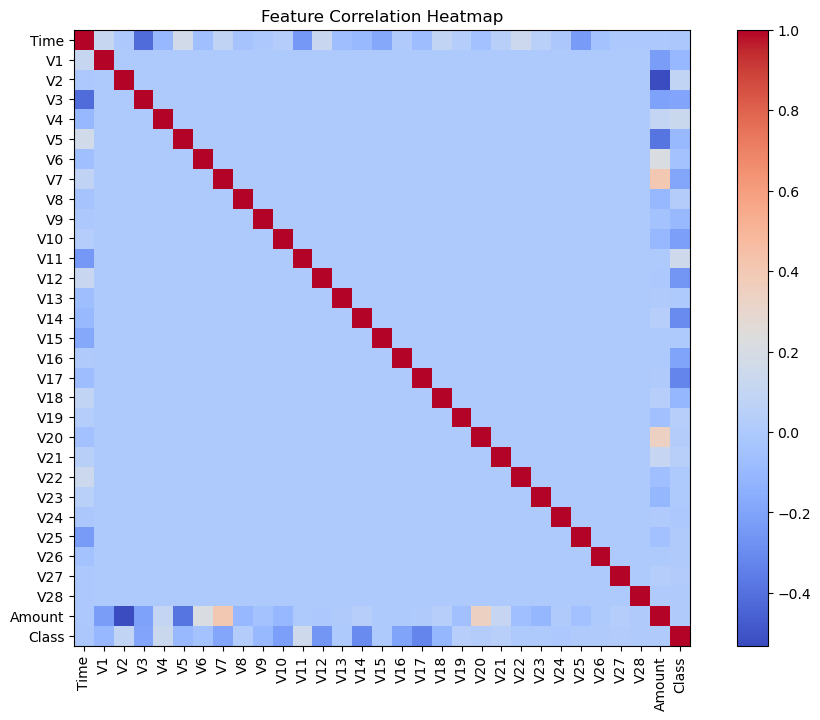

In [6]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df.corr()
plt.imshow(corr, cmap='coolwarm', interpolation = 'nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Heatmap')
plt.show()

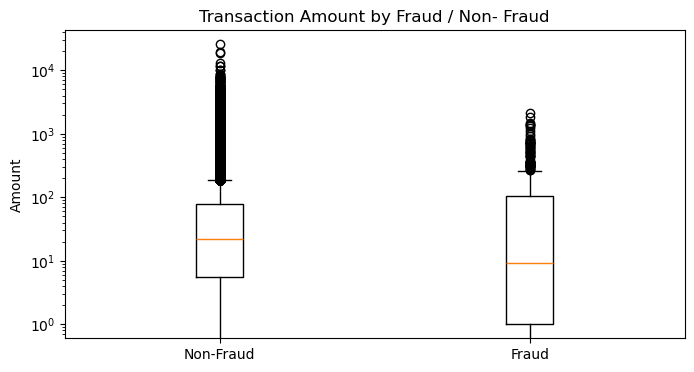

In [7]:
# Fraud vs Non-Fraud Amount
plt.figure(figsize=(8,4))
amount_nonfraud = df[df['Class']==0]['Amount']
amount_fraud = df[df['Class']==1]['Amount']
plt.boxplot([amount_nonfraud, amount_fraud], labels=['Non-Fraud', 'Fraud'])
plt.yscale('log')    # because amounts are skewed
plt.ylabel('Amount')
plt.title('Transaction Amount by Fraud / Non- Fraud')
plt.show()

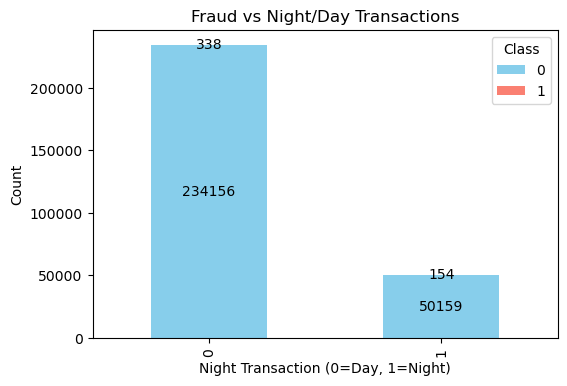

In [8]:
# Night vs Day Fraud
# Create Hour column from Time
df['Hour'] = (df['Time'] // 3600) % 24

# Create night flag
df['is_night'] = df['Hour'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)

# Group data
night_fraud = df.groupby(['is_night', 'Class']).size().unstack(fill_value=0)

# Plot
ax = night_fraud.plot(kind='bar', stacked=True, figsize=(6,4), color=['skyblue', 'salmon'])

plt.xlabel('Night Transaction (0=Day, 1=Night)')
plt.ylabel('Count')
plt.title('Fraud vs Night/Day Transactions')

for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%d')

plt.show()

In [9]:
# 3. Feature Engineering (basic)
# We will create a few straightforward features that often help:
# - Log_amount
# - amount_to_mean_ration (global mean)
# - is_high_amount (amount above 99th percentile)
df_fe = df.copy()
df_fe['log_amount'] = np.log1p(df_fe['Amount'])
global_mean = df_fe['Amount'].mean()
df_fe['amount_to_mean'] = df_fe['Amount'] / (global_mean + 1e-9)
p99 = df_fe['Amount'].quantile(0.99)
df_fe['is_high_amount'] = (df_fe['Amount'] > p99).astype(int)

# Hour/night
if 'Hour' in df_fe.columns:
    df_fe['is_night'] = df_fe['Hour'].isin([0,1,2,3,4,5,22,23]).astype(int)
else:
    df_fe['is_night'] = 0

# Drop columns we don't want to feed directly (Time kept only for refrence)
X = df_fe.drop(columns=[target_col])
y = df_fe[target_col].values

print('Feature engineering complete. X shape: ', X.shape)

Feature engineering complete. X shape:  (284807, 35)


In [10]:
# 4. Train / Test split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train: ', X_train.shape, 'Test:', X_test.shape)

# Scaling numeric features
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler = RobustScaler()
scaler.fit(X_train[numeric_features])

def prep(X_df):
    Xc = X_df.copy()
    Xc[numeric_features] = scaler.transform(Xc[numeric_features])
    # drop Time column to avoid Leakage of absolute timestamp; keep hour if present
    if 'Time' in Xc.columns:
        Xc = Xc.drop(columns=['Time'])
    return Xc

X_train_proc = prep(X_train)
X_test_proc = prep(X_test)
print('Processed data shapes:', X_train_proc.shape, X_test_proc.shape)

Train:  (227845, 35) Test: (56962, 35)
Processed data shapes: (227845, 34) (56962, 34)


In [11]:
# 5. Evaluation utilities
def evaluate_model(model, X_test, y_test, thresh=0.5, show_pr_curve=True):
    # obtain probabilities or scores
    if hasattr(model, 'predict_proba'):
        y_scores = model.predict_proba(X_test)[:,1]
    elif hasattr(model, 'decision_function'):
        s = model.decision_function(X_test)
        y_scores = (s - s.min())/(s.max()-s.min()+1e-9)
    else:
        y_scores = model.predict(X_test)
    y_pred = (y_scores >= thresh).astype(int)
    print('Classification report (threshold={}):'.format(thresh))
    print(classification_report(y_test, y_pred, digits=4))
    ap = average_precision_score(y_test, y_scores)
    roc = roc_auc_score(y_test, y_scores)
    cm = confusion_matrix(y_test, y_pred)
    print('Average precision (AUPRC):', ap)
    print('ROC AUC:', roc)
    print('Confusion matrix:\n', cm)
    if show_pr_curve:
        precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
        plt.figure(figsize=(6,4))
        plt.plot(recall, precision)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'PR curve (AP={ap:.4f})')
        plt.show()
    return {'ap': ap, 'roc': roc, 'scores': y_scores}

In [12]:
# 6. Train baseline models
trained_models = {}

# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga')
lr.fit(X_train_proc, y_train)
trained_models['LogisticRegression'] = lr
print('Trained Logistic Regression')

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train_proc, y_train)
trained_models['RandomForest'] = rf
print('Trained Random Forest')

# XGBoost 
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(np.sum(y_train==0)/np.sum(y_train==1)))
xgb_clf.fit(X_train_proc, y_train)
trained_models['XGBoost'] = xgb_clf
print('Trained XGBoost')

Trained Logistic Regression
Trained Random Forest
Trained XGBoost



=== Model: LogisticRegression ===
Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9999    0.9743    0.9869     56864
           1     0.0579    0.9184    0.1090        98

    accuracy                         0.9742     56962
   macro avg     0.5289    0.9463    0.5479     56962
weighted avg     0.9982    0.9742    0.9854     56962

Average precision (AUPRC): 0.7091145395787036
ROC AUC: 0.9698764793621444
Confusion matrix:
 [[55400  1464]
 [    8    90]]


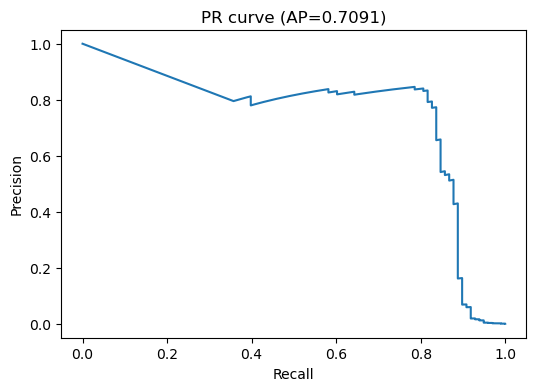


=== Model: RandomForest ===
Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9615    0.7653    0.8523        98

    accuracy                         0.9995     56962
   macro avg     0.9806    0.8826    0.9260     56962
weighted avg     0.9995    0.9995    0.9995     56962

Average precision (AUPRC): 0.8689747438567735
ROC AUC: 0.9572644864079565
Confusion matrix:
 [[56861     3]
 [   23    75]]


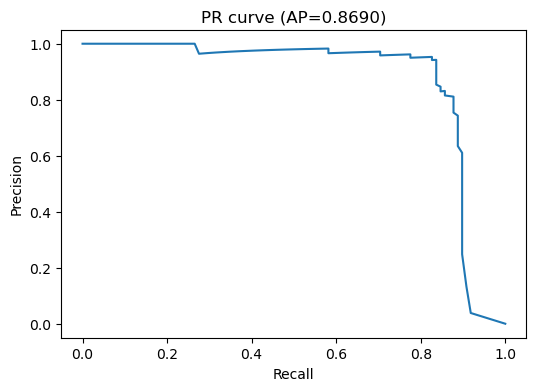


=== Model: XGBoost ===
Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9997     56864
           1     0.8791    0.8163    0.8466        98

    accuracy                         0.9995     56962
   macro avg     0.9394    0.9081    0.9232     56962
weighted avg     0.9995    0.9995    0.9995     56962

Average precision (AUPRC): 0.8802943133763176
ROC AUC: 0.9767434724311784
Confusion matrix:
 [[56853    11]
 [   18    80]]


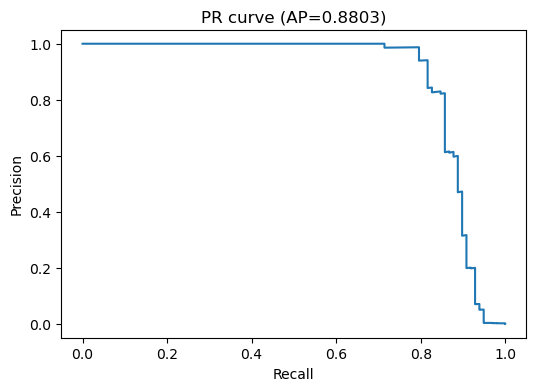

,model,AP,ROC_AUC
2,XGBoost,0.880294,0.976743
1,RandomForest,0.868975,0.957264
0,LogisticRegression,0.709115,0.969876


In [13]:
# 7. Evaluate all trained models
results = []
for name, model in trained_models.items():
    print('\n=== Model:', name, '===') 
    res = evaluate_model(model, X_test_proc, y_test)
    results.append({'model': name, 'AP': res['ap'], 'ROC_AUC': res['roc']})

res_df = pd.DataFrame(results).sort_values('AP', ascending=False)
res_df

In [14]:
# 10. Threshold tuning (example using best available model) and flag extraction
# Choose model with highest AP from res_df
best_model_name = res_df.iloc[0]['model']
model = trained_models[best_model_name]
print('Best model chosen:', best_model_name)

# Predict scores on test set and compute best threshold by F1 on test (for demonstration)
if hasattr(model, 'predict_proba'):
    y_scores = model.predict_proba(X_test_proc)[:,1]
else:
    s = model.decision_function(X_test_proc)
    y_scores = (s - s.min())/(s.max()-s.min()+1e-9)

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.nanargmax(f1_scores)
best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
print('Best threshold by F1 on test:', best_thresh)

# Prepare full dataset features and scores
X_all_proc = prep(X)
if hasattr(model, 'predict_proba'):
    all_scores = model.predict_proba(X_all_proc)[:,1]
else:
    s = model.decision_function(X_all_proc)
    all_scores = (s - s.min())/(s.max()-s.min()+1e-9)

df_out = df_fe.copy()
df_out['fraud_score'] = all_scores
df_out['pred_fraud'] = (df_out['fraud_score'] >= best_thresh).astype(int)
flagged = df_out[df_out['pred_fraud'] == 1].sort_values('fraud_score', ascending=False)
print('Flagged transactions count:', len(flagged))
flagged.head(20).to_csv('flagged_transactions.csv', index=False)
print('Saved flagged transactions to flagged_transactions.csv')

Best model chosen: XGBoost
Best threshold by F1 on test: 0.99290437
Flagged transactions count: 473
Saved flagged transactions to flagged_transactions.csv


In [15]:
# 11. Save the best model
# prefer saving scikit-learn models; for TF you'd save separately
joblib.dump(model, 'best_fraud_model.pkl')
print('Saved best model to best_fraud_model.pkl')

Saved best model to best_fraud_model.pkl


Before SMOTE: [227451    394]
After SMOTE: [227451 227451]
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9998    0.9994    0.9996     56864
           1     0.7241    0.8571    0.7850        98

    accuracy                         0.9992     56962
   macro avg     0.8619    0.9283    0.8923     56962
weighted avg     0.9993    0.9992    0.9992     56962

Average precision (AUPRC): 0.8713091866827928
ROC AUC: 0.9801116950719512
Confusion matrix:
 [[56832    32]
 [   14    84]]


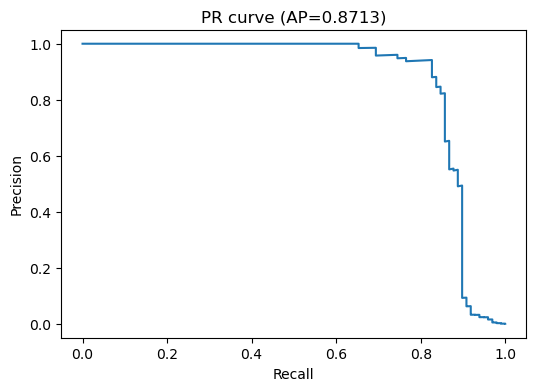

Improved model saved as best_fraud_model_v2.pkl


In [16]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import joblib

# -------------------------------
# 1) Handle imbalance with SMOTE
# -------------------------------
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_proc, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_sm))

# -------------------------------
# 2) Hyperparameter tuning
# -------------------------------
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 300, 500],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_model = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train_sm, y_train_sm)

best_model_v2 = search.best_estimator_

print("Best Params:", search.best_params_)

# -------------------------------
# 3) Evaluate tuned model
# -------------------------------
res_v2 = evaluate_model(best_model_v2, X_test_proc, y_test)

# -------------------------------
# 4) Save improved model
# -------------------------------
joblib.dump(best_model_v2, "best_fraud_model_v2.pkl")
print("Improved model saved as best_fraud_model_v2.pkl")